In [1]:
# open csv file with panda 
import pandas as pd
import random
import math
import numpy as np
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants

In [2]:
f_inp_in = "CY-DBP_competition_stream_competition_6days_0.inp"  #inp file for topology and hydraulics
f_msx_in = "CY-DBP_competition_stream_competition_6days_0.msx" # msx file for water quality and species

scenario = ScenarioSimulator(f_inp_in=f_inp_in, f_msx_in=f_msx_in)

ALL_NODES = scenario.get_topology().get_all_junctions() # get all nodes in the network

print(ALL_NODES)

scenario.close()

['distTreatbefore', 'distTreatafter', 'distafterTank', 'dist1', 'dist11', 'dist30', 'dist33', 'dist35', 'dist51', 'dist64', 'dist66', 'dist68', 'dist71', 'dist78', 'dist83', 'dist90', 'dist97', 'dist100', 'dist103', 'dist105', 'dist106', 'dist110', 'dist115', 'dist116', 'dist136', 'dist160', 'dist165', 'dist179', 'dist181', 'dist183', 'dist195', 'dist209', 'dist219', 'dist223', 'dist225', 'dist231', 'dist273', 'dist275', 'dist284', 'dist288', 'dist289', 'dist295', 'dist306', 'dist310', 'dist312', 'dist330', 'dist337', 'dist341', 'dist342', 'dist348', 'dist354', 'dist356', 'dist361', 'dist376', 'dist379', 'dist383', 'dist394', 'dist398', 'dist399', 'dist406', 'dist408', 'dist412', 'dist412_new', 'dist415', 'dist417', 'dist420', 'dist423', 'dist424', 'dist426', 'dist439', 'dist443', 'dist446', 'dist458', 'dist470', 'dist473', 'dist485', 'dist490', 'dist494', 'dist504', 'dist521', 'dist523', 'dist525', 'dist532', 'dist546', 'dist555', 'dist559', 'dist585', 'dist592', 'dist593', 'dist606',

In [8]:
def get_contaminated_nodes(df):
    contaminated_nodes = []
    for node in ALL_NODES:
        column_name_P = f"bulk_species_node [CUSTOM UNIT] at P @ {node}"
        if column_name_P in df.columns:
            if df[column_name_P].max() > 0:
                contaminated_nodes.append(node)

    return contaminated_nodes

df = pd.read_csv("scada_data_conta_node33.csv")
contaminated_nodes = get_contaminated_nodes(df)
print(contaminated_nodes)

['dist33', 'dist35', 'dist51', 'dist64', 'dist66', 'dist68', 'dist71', 'dist83', 'dist90', 'dist97', 'dist100', 'dist103', 'dist105', 'dist110', 'dist136', 'dist160', 'dist165', 'dist179', 'dist181', 'dist183', 'dist223', 'dist231', 'dist273', 'dist275', 'dist284', 'dist288', 'dist295', 'dist310', 'dist312', 'dist330', 'dist341', 'dist342', 'dist354', 'dist379', 'dist399', 'dist408', 'dist412', 'dist412_new', 'dist417', 'dist420', 'dist443', 'dist446', 'dist458', 'dist490', 'dist504', 'dist523', 'dist525', 'dist559', 'dist585', 'dist592', 'dist593', 'dist622', 'dist631', 'dist648', 'dist650', 'dist655', 'dist656', 'dist679', 'dist680', 'dist681', 'dist707', 'dist708', 'dist745', 'dist772', 'dist787', 'dist806', 'dist819', 'dist830', 'dist839', 'dist852', 'dist885', 'dist889', 'dist891', 'dist896', 'dist908', 'dist993', 'dist998', 'dist1025', 'dist1031']


In [9]:
def get_interesting_nodes(df, nodes):
    interesting_nodes = []
    for node in nodes: 
        column_name_cl = f"bulk_species_node [MG] at CL2 @ {node}"
        if column_name_cl in df.columns:
            if df[column_name_cl].max() > 0.2 :
                interesting_nodes.append(node)
    return interesting_nodes

contaminated_nodes = get_contaminated_nodes(df)
interesting_nodes = get_interesting_nodes(df, contaminated_nodes)
print(interesting_nodes)

['dist33', 'dist35', 'dist51', 'dist64', 'dist68', 'dist71', 'dist90', 'dist103', 'dist160', 'dist181', 'dist284', 'dist288', 'dist295', 'dist310', 'dist330', 'dist399', 'dist417', 'dist420', 'dist443', 'dist446', 'dist504', 'dist592', 'dist631', 'dist679', 'dist680', 'dist707', 'dist708', 'dist745', 'dist787', 'dist806']


In [ ]:
def get_node_where_significant_change(df_clean, df_contaminated, nodes):
    significant_change_nodes = []
    for node in nodes:
        column_name_cl = f"bulk_species_node [MG] at CL2 @ {node}"
        if column_name_cl in df_clean.columns and column_name_cl in df_contaminated.columns:
            mean_clean = df_clean[column_name_cl].mean() 
            mean_contaminated = df_contaminated[column_name_cl].mean() 
            difference = abs(mean_contaminated - mean_clean)
            if difference > 0.005:  # Threshold for significant change
                significant_change_nodes.append(node)
    return significant_change_nodes

df_clean = pd.read_csv("scada_data_clean.csv")
df_contaminated = pd.read_csv("scada_data_conta_node33.csv")
significant_change_nodes = get_node_where_significant_change(df_clean=df_clean, df_contaminated=df_contaminated, nodes=interesting_nodes)
print(significant_change_nodes)

['dist33', 'dist51', 'dist64', 'dist71', 'dist103', 'dist160', 'dist181', 'dist295', 'dist504', 'dist631', 'dist679', 'dist707', 'dist708', 'dist745']


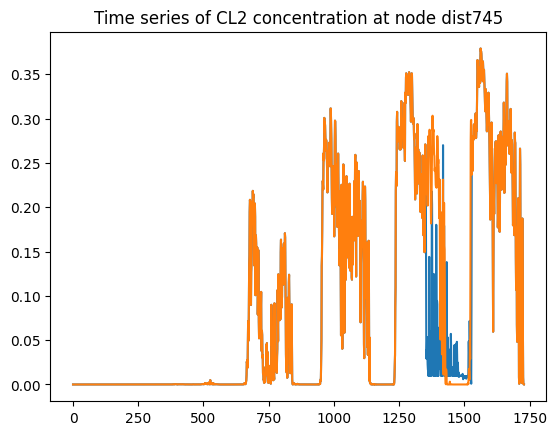

In [30]:
def plot_time_series(df, node):
    column_name_cl = f"bulk_species_node [MG] at CL2 @ {node}"
    if column_name_cl in df.columns:
        df[column_name_cl].plot(title=f"Time series of CL2 concentration at node {node}")
    else:
        print(f"Column {column_name_cl} not found in DataFrame.")

node = significant_change_nodes[13]
plot_time_series(df_contaminated, node=node)
plot_time_series(df_clean, node=node)

In [ ]:
def get_times_series(df, nodes): 
    time_series_data = {}
    for node in nodes:
        column_name_cl = f"bulk_species_node [MG] at CL2 @ {node}"
        if column_name_cl in df.columns:
            time_series_data[node] = df[column_name_cl].values
    return time_series_data

time_series_data = get_times_series(df_clean, significant_change_nodes)

In [ ]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit_predict(X)

kmeans.predict([[0, 0], [12, 3]])